# 05 — Climate Change Impact on HVAC Demand
**Project:** Data-Driven Analysis of HVAC Decarbonisation Pathways in Commercial Office Buildings Under Climate Change  
**Author:** Cheuk Fung Donald Man | Imperial College London | MEng Civil Engineering  
**Chapter 5 of thesis** — Climate-Change Contribution to HVAC Demand

---

## Research Question (Objective O3)
How much of today's HVAC energy demand is attributable to climate warming since 1988, and which climate zones are most exposed?

**Literature gap context:** Van Ruijven et al. (2019) project vigorous warming lifts climate-exposed energy demand **25–58% by 2050** `[VanRuijven2019]`. Petri & Caldeira (2015) show that per +1 °C global warming, US population-weighted CDD₁₈ rises ~20% and HDD₁₈ falls ~10% `[Petri2015]`. EPA (2021) observational data confirms a contiguous-US trend of CDD +1.59 dd/yr and HDD −4.59 dd/yr (1895–2020) `[EPA2021_CDD]`. This notebook quantifies those trends *inside* a calibrated EnergyPlus building simulation across three US climate zones.

**Sections:**
1. Setup — imports, paths, load data  
2. Annual degree-day computation (CDD₁₈, HDD₁₅) + trend plots  
3. Climate sensitivity regression — HVAC demand vs CDD / HDD  
4. Warming-attributable demand counterfactual (1988 vs 2005)  
5. Annual HVAC trend detection + statistical significance  
6. Save outputs (`climate_sensitivity.json`, figures)

## 1. Setup

In [1]:
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import linregress
import statsmodels.api as sm

warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from config import (
    CLIMATE_ZONES, EFFICIENCY_LEVELS, AMY_YEARS_PIVOT,
    CLIMATE_COLOURS, EFFICIENCY_COLOURS,
    J_TO_KWH, AREA_M2, TIMESTEP_MIN, OPS_HOUR_START, OPS_HOUR_END,
)

# ── Paths ──────────────────────────────────────────────────────────
DATA_IN  = Path('../data/processed')
FIG_OUT  = Path('../figures')
FIG_OUT.mkdir(parents=True, exist_ok=True)

# ── Degree-day base temperatures ──────────────────────────────────
# CDD₁₈: ASHRAE/NOAA standard balance-point [Biardeau2020, EPA2021_CDD]
# HDD₁₅: UK standard for commercial offices [DayGD2017]
CDD_BASE = 18.0
HDD_BASE = 15.0
SETPOINT = 22.0  # °C — building thermostat
STEPS_PER_HOUR = int(60 / TIMESTEP_MIN)   # 6 steps per hour at 10-min resolution

print(f'Climate zones  : {list(CLIMATE_ZONES.keys())}')
print(f'AMY years      : {AMY_YEARS_PIVOT}')
print(f'Efficiency lvls: {EFFICIENCY_LEVELS}')
print(f'Steps / hour   : {STEPS_PER_HOUR}')

Climate zones  : ['1A', '3C', '5A']
AMY years      : ['1988', '1990', '1996', '1997', '2004', '2005']
Efficiency lvls: ['Low', 'Standard', 'High']
Steps / hour   : 6


In [2]:
# ── Load 6-year AMY pivot dataset ──────────────────────────────────
# multi_year_pivot_raw.parquet: 6 AMY years × 3 climates × 3 efficiency × run_1
# = 54 annual simulations, produced in notebook 01 Section 12.
df = pd.read_parquet(DATA_IN / 'multi_year_pivot_raw.parquet')
df['year_int'] = df['year'].astype(int)

print(f'Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Years   : {sorted(df["year"].unique())}')
print(f'Climates: {sorted(df["climate"].unique())}')
print(f'Effic.  : {sorted(df["efficiency"].unique())}')
print(f'Runs    : {df["run"].unique()}')
print(f'\nRows per (climate, efficiency, year):')
print(df.groupby(['climate', 'efficiency', 'year']).size().unstack('year'))

Loaded  : 2,838,240 rows × 24 columns
Years   : ['1988', '1990', '1996', '1997', '2004', '2005']
Climates: ['1A', '3C', '5A']
Effic.  : ['High', 'Low', 'Standard']
Runs    : ['run_1']

Rows per (climate, efficiency, year):
year                 1988   1990   1996   1997   2004   2005
climate efficiency                                          
1A      High        52560  52560  52560  52560  52560  52560
        Low         52560  52560  52560  52560  52560  52560
        Standard    52560  52560  52560  52560  52560  52560
3C      High        52560  52560  52560  52560  52560  52560
        Low         52560  52560  52560  52560  52560  52560
        Standard    52560  52560  52560  52560  52560  52560
5A      High        52560  52560  52560  52560  52560  52560
        Low         52560  52560  52560  52560  52560  52560
        Standard    52560  52560  52560  52560  52560  52560


## 2. Annual Degree-Day Computation

**Method:** From the 10-minute OAT series, compute annual cooling and heating degree-days by summing hourly thermal exposure above/below the balance-point temperature and dividing by 24 to yield °C·days.

$$\text{CDD}_{18} = \sum_{t=1}^{N} \frac{\max(0,\; T_t - 18)}{n_{\text{steps/day}}}$$

$$\text{HDD}_{15} = \sum_{t=1}^{N} \frac{\max(0,\; 15 - T_t)}{n_{\text{steps/day}}}$$

where $N$ = 52,560 steps/year (10-min resolution), $n_{\text{steps/day}} = 144$.

The 18 °C CDD balance point follows ASHRAE/NOAA convention `[EPA2021_CDD]`, `[Biardeau2020]`. The 15 °C HDD base follows UK standard for commercial offices `[DayGD2017]`. Sensitivity to base temperature is discussed in Section 2.4 of the thesis — Dirks et al. (2015) show a fixed 18.3 °C base can overstate climate change by up to 14 percentage points `[Dirks2015]`.

In [3]:
def compute_degree_days(grp, cdd_base=CDD_BASE, hdd_base=HDD_BASE):
    """Annual CDD and HDD from 10-min OAT series."""
    oat = grp['oat_c'].values
    steps_per_day = STEPS_PER_HOUR * 24
    cdd = np.sum(np.maximum(0, oat - cdd_base)) / steps_per_day
    hdd = np.sum(np.maximum(0, hdd_base - oat)) / steps_per_day
    return pd.Series({'CDD': cdd, 'HDD': hdd})

# OAT is independent of efficiency level — use Standard to avoid triple-counting
dd = (
    df[df['efficiency'] == 'Standard']
    .groupby(['climate', 'year', 'year_int'])
    .apply(compute_degree_days)
    .reset_index()
    .sort_values(['climate', 'year_int'])
)

print('Annual degree days per (climate, year):')
print(dd.pivot_table(index='year', columns='climate', values=['CDD', 'HDD']).round(0).to_string())

Annual degree days per (climate, year):
            CDD                 HDD               
climate      1A     3C     5A    1A     3C      5A
year                                              
1988     2507.0  190.0  624.0  47.0  810.0  3088.0
1990     2685.0  181.0  349.0   9.0  933.0  2646.0
1996     2505.0  166.0  242.0  72.0  713.0  3316.0
1997     2603.0  205.0  316.0  31.0  660.0  3032.0
2004     2492.0  194.0  301.0  34.0  667.0  2656.0
2005     2483.0  120.0  617.0  33.0  625.0  2692.0


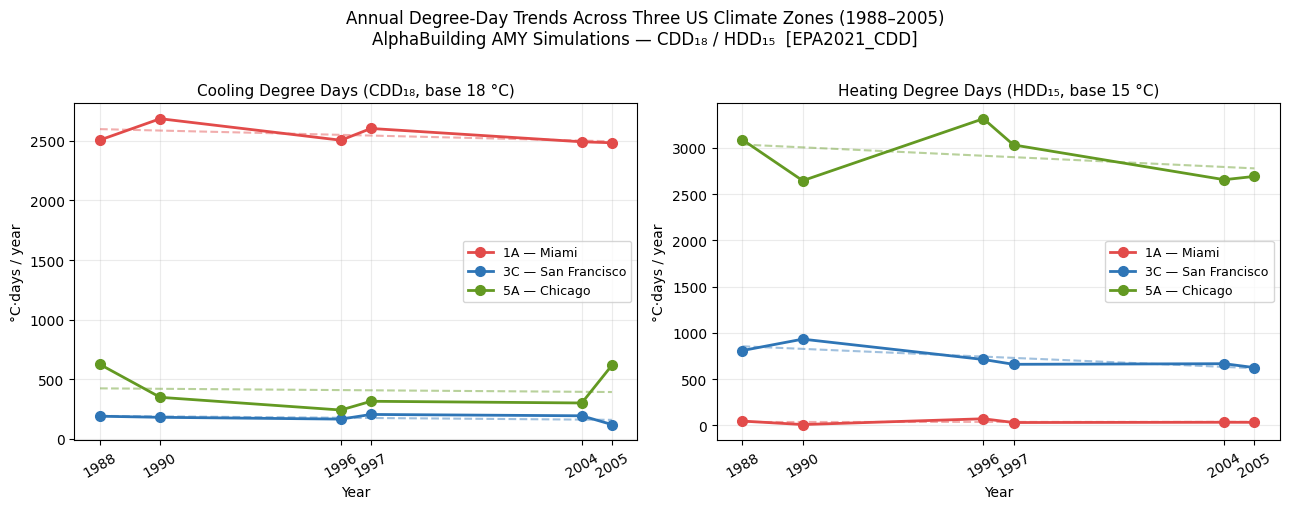

Saved → figures/05_cdd_hdd_trends.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Annual Degree-Day Trends Across Three US Climate Zones (1988–2005)\n'
    'AlphaBuilding AMY Simulations — CDD₁₈ / HDD₁₅  [EPA2021_CDD]',
    fontsize=12, y=1.01
)

for clim, grp in dd.groupby('climate'):
    color = CLIMATE_COLOURS[clim]
    city  = CLIMATE_ZONES[clim].split(',')[0]
    label = f'{clim} — {city}'
    g = grp.sort_values('year_int')

    axes[0].plot(g['year_int'], g['CDD'], 'o-', color=color, label=label, lw=2, ms=7)
    axes[1].plot(g['year_int'], g['HDD'], 'o-', color=color, label=label, lw=2, ms=7)

    # Trend lines
    for ax, col in zip(axes, ['CDD', 'HDD']):
        m, b, r, p, _ = linregress(g['year_int'], g[col])
        xs = np.array([g['year_int'].min(), g['year_int'].max()])
        ax.plot(xs, m * xs + b, '--', color=color, alpha=0.45, lw=1.5)

for ax, title, ylabel in zip(
    axes,
    ['Cooling Degree Days (CDD₁₈, base 18 °C)', 'Heating Degree Days (HDD₁₅, base 15 °C)'],
    ['°C·days / year', '°C·days / year'],
):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.set_xticks(sorted(dd['year_int'].unique()))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIG_OUT / '05_cdd_hdd_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_cdd_hdd_trends.png')

In [5]:
# ── Degree-day trends summary ──────────────────────────────────────
print('Degree-day trend summary (linear fit over 6 AMY years):')
for clim, grp in dd.groupby('climate'):
    g = grp.sort_values('year_int')
    m_cdd, b, r_cdd, p_cdd, _ = linregress(g['year_int'], g['CDD'])
    m_hdd, b, r_hdd, p_hdd, _ = linregress(g['year_int'], g['HDD'])
    city = CLIMATE_ZONES[clim].split(',')[0]
    print(f'  {clim} {city}: '
          f'ΔCDD = {m_cdd:+.1f} dd/yr (R²={r_cdd**2:.2f}, p={p_cdd:.3f})  '
          f'ΔHDD = {m_hdd:+.1f} dd/yr (R²={r_hdd**2:.2f}, p={p_hdd:.3f})')

Degree-day trend summary (linear fit over 6 AMY years):
  1A Miami: ΔCDD = -6.0 dd/yr (R²=0.27, p=0.293)  ΔHDD = +0.1 dd/yr (R²=0.00, p=0.956)
  3C San Francisco: ΔCDD = -1.9 dd/yr (R²=0.20, p=0.372)  ΔHDD = -13.9 dd/yr (R²=0.70, p=0.038)
  5A Chicago: ΔCDD = -1.8 dd/yr (R²=0.01, p=0.888)  ΔHDD = -15.1 dd/yr (R²=0.14, p=0.461)


## 3. Climate Sensitivity Regression

**Method:** For each (climate zone, efficiency level) combination, fit an OLS regression:

$$\text{Annual HVAC (MWh)} = \alpha + \beta_{\text{CDD}} \cdot \text{CDD}_{18} + \beta_{\text{HDD}} \cdot \text{HDD}_{15} + \varepsilon$$

The coefficients $\beta_{\text{CDD}}$ and $\beta_{\text{HDD}}$ are the **climate sensitivity** of the building in MWh per degree-day — the amount of additional annual HVAC energy driven by one more degree-day of cooling or heating demand. Santamouris (2014) reports a ~0.7 kWh/m² per K cooling energy elasticity for commercial buildings `[Santamouris2014]`; the results here can be compared on a per-m² basis (building area = 4,982 m²).

**Note on sample size:** With only 6 AMY years, the regression fits 6 data points per (climate, efficiency) pair. This is sufficient for an indicative sensitivity but p-values should be interpreted conservatively; the pattern across efficiency levels and climates is the primary result.

In [6]:
# ── Annual HVAC per (climate, efficiency, year) ────────────────────
def compute_annual_hvac(grp):
    return pd.Series({
        'annual_hvac_mwh':    grp['hvac_kwh'].sum() / 1000,
        'annual_cooling_mwh': grp['cooling_kwh'].sum() / 1000,
        'annual_heating_mwh': grp['heating_kwh'].sum() / 1000,
        # Peak average power in kW: kWh per 10-min step × 6 steps/hr = avg kW
        'peak_hvac_kw':       grp['hvac_kwh'].max() * STEPS_PER_HOUR,
        'n_rows':             len(grp),
    })

ann = (
    df.groupby(['climate', 'efficiency', 'year', 'year_int'])
    .apply(compute_annual_hvac)
    .reset_index()
)

# Merge in degree days (same for all efficiency levels)
ann = ann.merge(
    dd[['climate', 'year', 'CDD', 'HDD']],
    on=['climate', 'year'],
    how='left'
)

print('Annual HVAC (MWh) — Standard efficiency:')
std = ann[ann['efficiency'] == 'Standard']
print(std.pivot_table(index='year', columns='climate', values='annual_hvac_mwh').round(1).to_string())

Annual HVAC (MWh) — Standard efficiency:
climate     1A     3C     5A
year                        
1988     261.4  122.8  207.1
1990     266.8  115.0  176.6
1996     263.8  118.7  190.4
1997     263.4  126.2  188.5
2004     260.2  123.8  191.4
2005     265.8  120.6  195.3


In [7]:
# ── Fit OLS regressions ────────────────────────────────────────────
sens_results = []

for clim in CLIMATE_ZONES:
    for eff in EFFICIENCY_LEVELS:
        sub = ann[(ann['climate'] == clim) & (ann['efficiency'] == eff)].sort_values('year_int')
        if len(sub) < 4:
            continue

        X = sm.add_constant(sub[['CDD', 'HDD']])
        model = sm.OLS(sub['annual_hvac_mwh'], X).fit()

        beta_cdd = model.params.get('CDD', np.nan)
        beta_hdd = model.params.get('HDD', np.nan)
        p_cdd    = model.pvalues.get('CDD', np.nan)
        p_hdd    = model.pvalues.get('HDD', np.nan)

        sens_results.append({
            'climate': clim, 'efficiency': eff,
            'beta_CDD_mwh_per_dd': beta_cdd,
            'beta_HDD_mwh_per_dd': beta_hdd,
            'p_CDD': p_cdd, 'p_HDD': p_hdd,
            'R2_adj': model.rsquared_adj,
            # Per-m² sensitivity (kWh/m²/dd)
            'beta_CDD_kwh_m2_dd': beta_cdd * 1000 / AREA_M2,
            'beta_HDD_kwh_m2_dd': beta_hdd * 1000 / AREA_M2,
        })

sens_df = pd.DataFrame(sens_results)

print('Climate sensitivity regression results:')
print('-' * 90)
print(f'{"Climate":<6} {"Effic.":<10} {"β_CDD (MWh/dd)":<18} {"β_HDD (MWh/dd)":<18} {"R²_adj":<10} {"β_CDD p":<12} {"β_HDD p"}')
print('-' * 90)
for _, row in sens_df.iterrows():
    print(f"{row['climate']:<6} {row['efficiency']:<10} "
          f"{row['beta_CDD_mwh_per_dd']:>8.3f} {'*' if row['p_CDD'] < 0.05 else ' ':<9} "
          f"{row['beta_HDD_mwh_per_dd']:>8.3f} {'*' if row['p_HDD'] < 0.05 else ' ':<9} "
          f"{row['R2_adj']:>8.3f}   "
          f"{row['p_CDD']:>8.3f}   {row['p_HDD']:.3f}")
print('\n* = p < 0.05')
print('\nβ_CDD per m² (kWh/m²/dd), Standard efficiency — cf. Santamouris (2014) ~0.7 kWh/m²/K [Santamouris2014]:')
print(sens_df[sens_df['efficiency']=='Standard'][['climate','beta_CDD_kwh_m2_dd','beta_HDD_kwh_m2_dd']].to_string(index=False))

Climate sensitivity regression results:
------------------------------------------------------------------------------------------
Climate Effic.     β_CDD (MWh/dd)     β_HDD (MWh/dd)     R²_adj     β_CDD p      β_HDD p
------------------------------------------------------------------------------------------
1A     Low           0.008             -0.220              0.565      0.790   0.146
1A     Standard      0.016             -0.004             -0.176      0.484   0.965
1A     High          0.001             -0.104              0.253      0.972   0.257
3C     Low           0.028             -0.024             -0.211      0.768   0.366
3C     Standard      0.085             -0.029 *            0.698      0.087   0.046
3C     High          0.096              0.020              0.780      0.060   0.101
5A     Low           0.040              0.028              0.256      0.264   0.212
5A     Standard      0.045              0.018              0.480      0.104   0.221
5A     High      

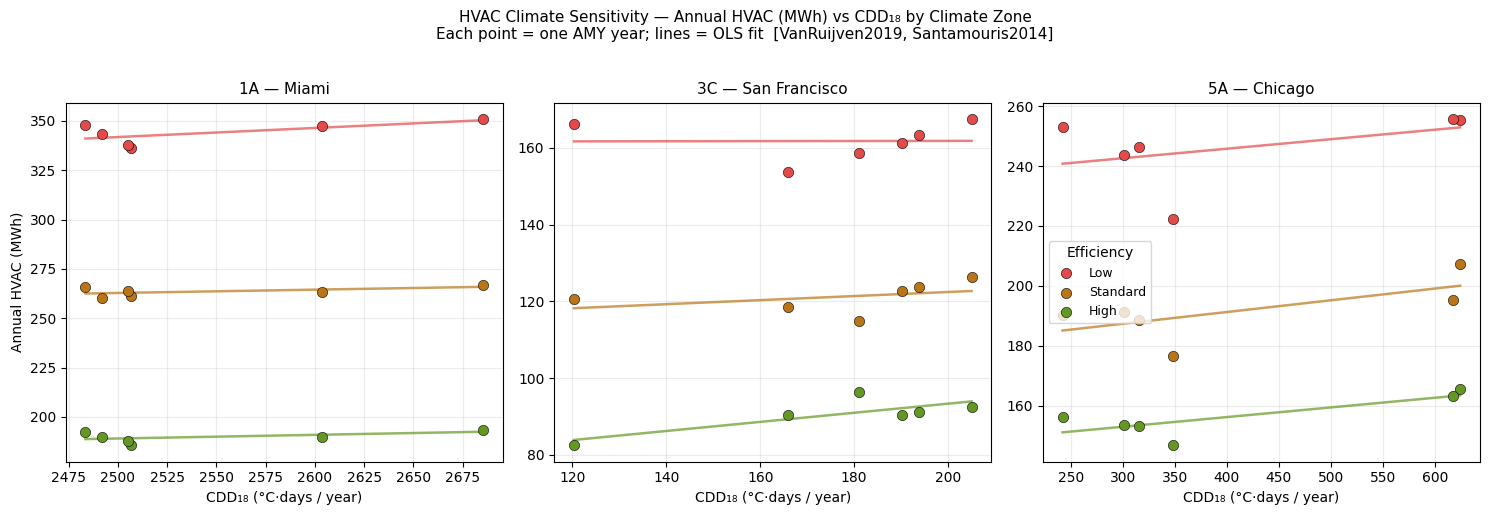

Saved → figures/05_climate_sensitivity.png


In [8]:
# ── Plot: HVAC vs CDD scatter + OLS fit per climate ───────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'HVAC Climate Sensitivity — Annual HVAC (MWh) vs CDD₁₈ by Climate Zone\n'
    'Each point = one AMY year; lines = OLS fit  [VanRuijven2019, Santamouris2014]',
    fontsize=11, y=1.02
)

for ax, clim in zip(axes, CLIMATE_ZONES):
    for eff in EFFICIENCY_LEVELS:
        sub = ann[(ann['climate'] == clim) & (ann['efficiency'] == eff)].sort_values('year_int')
        color = EFFICIENCY_COLOURS[eff]
        ax.scatter(sub['CDD'], sub['annual_hvac_mwh'], color=color, zorder=3,
                   s=55, edgecolors='k', linewidths=0.4, label=eff)

        xs = np.linspace(sub['CDD'].min(), sub['CDD'].max(), 50)
        m, b, *_ = linregress(sub['CDD'], sub['annual_hvac_mwh'])
        ax.plot(xs, m * xs + b, '-', color=color, alpha=0.7, lw=1.8)

    city = CLIMATE_ZONES[clim].split(',')[0]
    ax.set_title(f'{clim} — {city}', fontsize=11)
    ax.set_xlabel('CDD₁₈ (°C·days / year)')
    ax.set_ylabel('Annual HVAC (MWh)' if ax is axes[0] else '')
    ax.grid(alpha=0.25)
    if ax is axes[-1]:
        ax.legend(title='Efficiency', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_OUT / '05_climate_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_climate_sensitivity.png')

## 4. Warming-Attributable Demand Counterfactual

**Research question:** How much additional HVAC demand can be attributed to the climate warming between 1988 and 2005, across climate zones and efficiency levels?

**Method:** Since the AlphaBuilding dataset contains the *same building* (same design, same occupancy schedule run_1) simulated under different AMY weather years, the observed annual HVAC difference between 1988 and 2005 for the *same efficiency level* is a controlled counterfactual — isolating the weather-year effect.

$$\Delta_{\text{climate}} = \text{HVAC}_{2005, \text{Standard}} - \text{HVAC}_{1988, \text{Standard}}$$

The XGBoost v2 model (R² = 0.9973) is then used to re-predict HVAC for both weather years, confirming that the model captures the weather-year sensitivity and validating it as a counterfactual-scenario engine for notebooks 06 and 07. The model was trained on scaled features (`scaler_X_v2`) and a scaled target (`scaler_y_v2`); both transforms are applied here.

**Interpretation:** The warming-attributable demand captures both the direct temperature effect (more cooling-degree days) and indirect effects (changed diurnal OAT profile). Van Ruijven et al. (2019) `[VanRuijven2019]` and Petri & Caldeira (2015) `[Petri2015]` both project continued intensification of this effect through 2050.

In [9]:
# ── Observed warming-attributable demand (1988 vs 2005) ────────────
counterfactual_rows = []

for clim in CLIMATE_ZONES:
    for eff in EFFICIENCY_LEVELS:
        sub_1988 = ann[(ann['climate'] == clim) & (ann['efficiency'] == eff) & (ann['year'] == '1988')]
        sub_2005 = ann[(ann['climate'] == clim) & (ann['efficiency'] == eff) & (ann['year'] == '2005')]

        if sub_1988.empty or sub_2005.empty:
            continue

        hvac_1988 = sub_1988['annual_hvac_mwh'].values[0]
        hvac_2005 = sub_2005['annual_hvac_mwh'].values[0]
        cool_1988 = sub_1988['annual_cooling_mwh'].values[0]
        cool_2005 = sub_2005['annual_cooling_mwh'].values[0]
        heat_1988 = sub_1988['annual_heating_mwh'].values[0]
        heat_2005 = sub_2005['annual_heating_mwh'].values[0]

        delta_total = hvac_2005 - hvac_1988
        delta_pct   = 100 * delta_total / hvac_1988

        counterfactual_rows.append({
            'climate': clim, 'efficiency': eff,
            'hvac_1988_mwh': hvac_1988, 'hvac_2005_mwh': hvac_2005,
            'delta_total_mwh': delta_total, 'delta_pct': delta_pct,
            'delta_cooling_mwh': cool_2005 - cool_1988,
            'delta_heating_mwh': heat_2005 - heat_1988,
            'CDD_1988': sub_1988['CDD'].values[0], 'CDD_2005': sub_2005['CDD'].values[0],
            'HDD_1988': sub_1988['HDD'].values[0], 'HDD_2005': sub_2005['HDD'].values[0],
        })

cf = pd.DataFrame(counterfactual_rows)

print('Warming-attributable demand (2005 vs 1988 — same building, different weather year):')
print('=' * 80)
for _, row in cf[cf['efficiency'] == 'Standard'].iterrows():
    city = CLIMATE_ZONES[row['climate']].split(',')[0]
    print(f"\n  {row['climate']} {city} (Standard):")
    print(f"    1988 HVAC: {row['hvac_1988_mwh']:>8.1f} MWh  (CDD={row['CDD_1988']:.0f}, HDD={row['HDD_1988']:.0f})")
    print(f"    2005 HVAC: {row['hvac_2005_mwh']:>8.1f} MWh  (CDD={row['CDD_2005']:.0f}, HDD={row['HDD_2005']:.0f})")
    print(f"    Δ (warming-attr.): {row['delta_total_mwh']:>+.1f} MWh  ({row['delta_pct']:+.1f}%)")
    print(f"      of which: Δcooling = {row['delta_cooling_mwh']:+.1f} MWh, Δheating = {row['delta_heating_mwh']:+.1f} MWh")

Warming-attributable demand (2005 vs 1988 — same building, different weather year):

  1A Miami (Standard):
    1988 HVAC:    261.4 MWh  (CDD=2507, HDD=47)
    2005 HVAC:    265.8 MWh  (CDD=2483, HDD=33)
    Δ (warming-attr.): +4.4 MWh  (+1.7%)
      of which: Δcooling = +6.6 MWh, Δheating = -0.4 MWh

  3C San Francisco (Standard):
    1988 HVAC:    122.8 MWh  (CDD=190, HDD=810)
    2005 HVAC:    120.6 MWh  (CDD=120, HDD=625)
    Δ (warming-attr.): -2.2 MWh  (-1.8%)
      of which: Δcooling = +7.1 MWh, Δheating = -9.5 MWh

  5A Chicago (Standard):
    1988 HVAC:    207.1 MWh  (CDD=624, HDD=3088)
    2005 HVAC:    195.3 MWh  (CDD=617, HDD=2692)
    Δ (warming-attr.): -11.8 MWh  (-5.7%)
      of which: Δcooling = +7.8 MWh, Δheating = -19.7 MWh


In [10]:
# ── XGBoost counterfactual re-prediction ──────────────────────────
# The model was trained on scaled features (scaler_X_v2) and scaled
# target (scaler_y_v2); both transforms are required at inference.

model_xgb  = joblib.load(DATA_IN / 'model_xgb_v2.pkl')
scaler_X   = joblib.load(DATA_IN / 'scaler_X_v2.pkl')
scaler_y   = joblib.load(DATA_IN / 'scaler_y_v2.pkl')
with open(DATA_IN / 'feature_sets_v2.json') as fh:
    fs_v2 = json.load(fh)
FEATURES   = fs_v2['FULL_FEATURES']         # 34-feature set (order must match training)
SCALE_COLS = fs_v2['CONTINUOUS_SCALE_COLS']  # 20 continuous cols to standardise
print(f'Model features : {len(FEATURES)}')
print(f'Scaled cols    : {len(SCALE_COLS)}')
print(f'scaler_y       : mean={scaler_y.mean_[0]:.3f} kWh, scale={scaler_y.scale_[0]:.3f} kWh')

def build_features_and_predict(df_raw, model, scaler_X, scaler_y, features, scale_cols):
    """Build 34-feature matrix, standardise continuous cols, predict kWh."""
    d = df_raw.copy().sort_values(
        ['climate', 'efficiency', 'year', 'month', 'dayofweek', 'hour', 'minute']
    ).reset_index(drop=True)

    # Derived scalar features
    d['oat_dev']     = d['oat_c']         - 22.0
    d['wetbulb_dev'] = d['wetbulb_c']     - 22.0
    d['oat_sq']      = d['oat_c'] ** 2
    d['indoor_dev']  = d['indoor_temp_c'] - 22.0

    # Cyclic time encodings (not scaled)
    d['hour_sin']  = np.sin(2 * np.pi * d['hour']      / 24)
    d['hour_cos']  = np.cos(2 * np.pi * d['hour']      / 24)
    d['month_sin'] = np.sin(2 * np.pi * d['month']     / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month']     / 12)
    d['dow_sin']   = np.sin(2 * np.pi * d['dayofweek'] /  7)
    d['dow_cos']   = np.cos(2 * np.pi * d['dayofweek'] /  7)

    # Autoregressive lag/rolling features — per simulation group
    for (clim, eff, yr), g in d.groupby(['climate', 'efficiency', 'year']):
        idx = g.index
        v   = g['hvac_kwh']
        d.loc[idx, 'hvac_lag1']    = v.shift(1).values
        d.loc[idx, 'hvac_lag6']    = v.shift(6).values
        d.loc[idx, 'hvac_lag144']  = v.shift(144).values
        d.loc[idx, 'hvac_roll1h']  = v.rolling(6,   min_periods=1).mean().values
        d.loc[idx, 'hvac_roll24h'] = v.rolling(144, min_periods=1).mean().values

    # OHE (not scaled)
    for z in ['1A', '3C', '5A']:
        d[f'climate_{z}'] = (d['climate'] == z).astype(int)
    for e in ['High', 'Low', 'Standard']:
        d[f'efficiency_{e}'] = (d['efficiency'] == e).astype(int)

    d = d.dropna(subset=features)

    # Standardise continuous cols; predict; inverse-transform to kWh
    X = d[features].copy()
    X[scale_cols] = scaler_X.transform(X[scale_cols])
    preds_scaled = model.predict(X)
    d['hvac_pred_kwh'] = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
    return d

print('\nBuilding features and predicting for 1988 + 2005, Standard efficiency...')
df_xgb_input = df[
    (df['efficiency'] == 'Standard') & (df['year'].isin(['1988', '2005']))
].copy()

df_feat = build_features_and_predict(
    df_xgb_input, model_xgb, scaler_X, scaler_y, FEATURES, SCALE_COLS
)
print(f'Predictions complete for {len(df_feat):,} rows.')

Model features : 34
Scaled cols    : 20
scaler_y       : mean=3.692 kWh, scale=4.125 kWh

Building features and predicting for 1988 + 2005, Standard efficiency...
Predictions complete for 314,496 rows.


In [11]:
# ── Actual vs XGBoost predicted annual HVAC ───────────────────────
xgb_annual = (
    df_feat
    .groupby(['climate', 'year'])
    .agg(
        actual_mwh  = ('hvac_kwh',      lambda x: x.sum() / 1000),
        pred_mwh    = ('hvac_pred_kwh', lambda x: x.sum() / 1000),
    )
    .reset_index()
    .sort_values(['climate', 'year'])
)
xgb_annual['err_pct'] = 100 * (xgb_annual['pred_mwh'] - xgb_annual['actual_mwh']) / xgb_annual['actual_mwh']

print('XGBoost validation (Standard, 1988 vs 2005):')
print(xgb_annual.to_string(index=False))

print('\nWarming-attributable Δ — observed vs XGBoost-predicted (2005 − 1988):')
for clim in CLIMATE_ZONES:
    sub = xgb_annual[xgb_annual['climate'] == clim].sort_values('year')
    if len(sub) == 2:
        da = sub['actual_mwh'].iloc[1] - sub['actual_mwh'].iloc[0]
        dp = sub['pred_mwh'].iloc[1]   - sub['pred_mwh'].iloc[0]
        city = CLIMATE_ZONES[clim].split(',')[0]
        print(f'  {clim} {city}: observed Δ = {da:+.1f} MWh,  XGBoost Δ = {dp:+.1f} MWh')

XGBoost validation (Standard, 1988 vs 2005):
climate year  actual_mwh   pred_mwh  err_pct
     1A 1988  261.372833 270.255438 3.398442
     1A 2005  265.813766 275.024719 3.465190
     3C 1988  122.735275 130.913258 6.663107
     3C 2005  120.578383 125.512031 4.091653
     5A 1988  206.692490 220.055984 6.465399
     5A 2005  195.129905 206.814906 5.988319

Warming-attributable Δ — observed vs XGBoost-predicted (2005 − 1988):
  1A Miami: observed Δ = +4.4 MWh,  XGBoost Δ = +4.8 MWh
  3C San Francisco: observed Δ = -2.2 MWh,  XGBoost Δ = -5.4 MWh
  5A Chicago: observed Δ = -11.6 MWh,  XGBoost Δ = -13.2 MWh


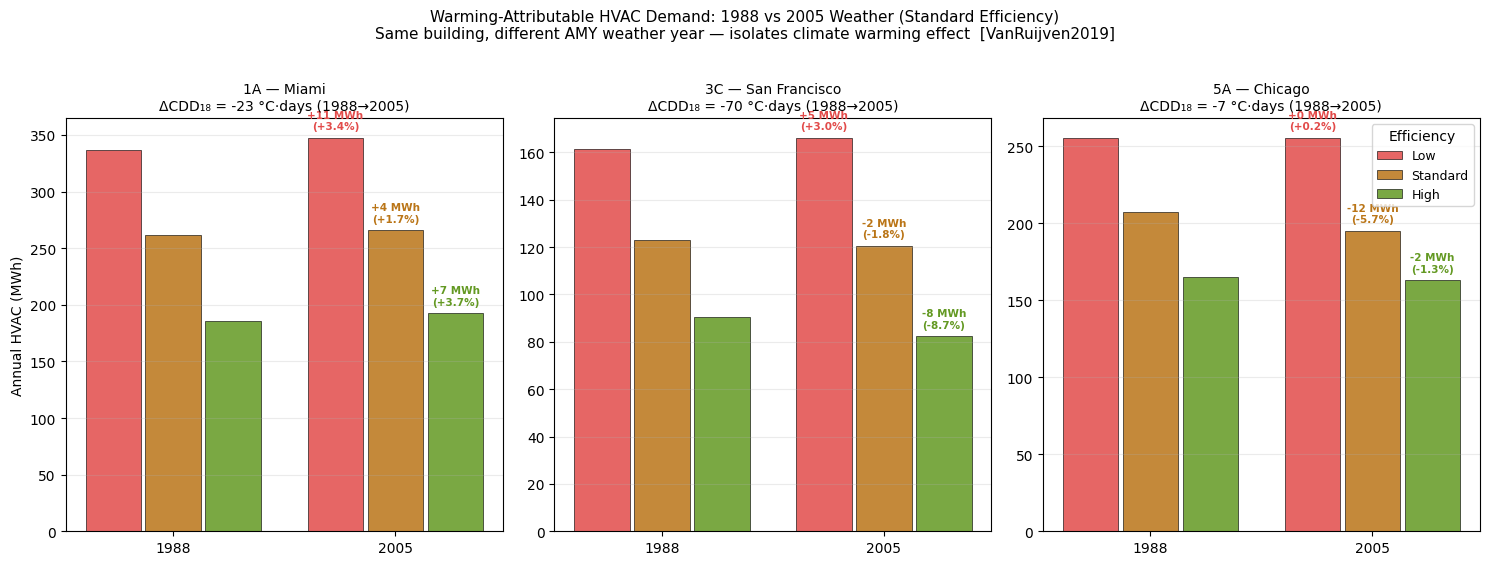

Saved → figures/05_warming_counterfactual.png


In [12]:
# ── Plot warming counterfactual ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(
    'Warming-Attributable HVAC Demand: 1988 vs 2005 Weather (Standard Efficiency)\n'
    'Same building, different AMY weather year — isolates climate warming effect  [VanRuijven2019]',
    fontsize=11, y=1.02
)

years_show = ['1988', '2005']
x_pos = np.arange(len(years_show))

for ax, clim in zip(axes, CLIMATE_ZONES):
    sub = cf[cf['climate'] == clim]

    for i, eff in enumerate(EFFICIENCY_LEVELS):
        row = sub[sub['efficiency'] == eff]
        if row.empty:
            continue
        row = row.iloc[0]
        vals = [row['hvac_1988_mwh'], row['hvac_2005_mwh']]
        color = EFFICIENCY_COLOURS[eff]
        offset = (i - 1) * 0.27
        ax.bar(x_pos + offset, vals, width=0.25, color=color,
               alpha=0.85, label=eff, edgecolor='k', linewidth=0.5)

        delta = row['delta_total_mwh']
        ax.annotate(
            f'{delta:+.0f} MWh\n({row["delta_pct"]:+.1f}%)',
            xy=(x_pos[1] + offset, vals[1]),
            xytext=(0, 6), textcoords='offset points',
            ha='center', fontsize=7.5, color=color, fontweight='bold'
        )

    city = CLIMATE_ZONES[clim].split(',')[0]
    std_row = cf[(cf['climate'] == clim) & (cf['efficiency'] == 'Standard')].iloc[0]
    cdd_delta = std_row['CDD_2005'] - std_row['CDD_1988']
    ax.set_title(f'{clim} — {city}\nΔCDD₁₈ = {cdd_delta:+.0f} °C·days (1988→2005)', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(years_show, fontsize=10)
    ax.set_ylabel('Annual HVAC (MWh)' if ax is axes[0] else '')
    ax.grid(axis='y', alpha=0.25)
    if ax is axes[-1]:
        ax.legend(title='Efficiency', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_OUT / '05_warming_counterfactual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_warming_counterfactual.png')

## 5. Annual HVAC Trend Detection

**Method:** For each (climate, efficiency) combination, fit a simple linear regression of annual HVAC demand against year:

$$\text{Annual HVAC (MWh)} = \alpha + \beta_{\text{year}} \cdot \text{year} + \varepsilon$$

The slope $\beta_{\text{year}}$ (MWh/year) represents the trend rate. Trend significance is assessed via the t-test p-value. Note that with only 6 data points and non-uniform year spacing (gaps between AMY years), these tests are indicative rather than conclusive — they should be interpreted alongside the CDD/HDD trends in Section 2, which reflect the underlying driver `[EPA2021_CDD]`.

**Expected finding:** Miami (1A) should show a positive HVAC trend driven by rising CDD. Chicago (5A) may show a mixed trend — rising cooling demand partially offset by falling heating demand. San Francisco (3C) should be relatively flat, consistent with its stable marine climate.

In [13]:
# ── Annual trend regression per (climate, efficiency) ─────────────
trend_results = []

for clim in CLIMATE_ZONES:
    for eff in EFFICIENCY_LEVELS:
        sub = ann[(ann['climate'] == clim) & (ann['efficiency'] == eff)].sort_values('year_int')
        if len(sub) < 4:
            continue

        slope, intercept, r, p, se = linregress(sub['year_int'], sub['annual_hvac_mwh'])
        mean_hvac = sub['annual_hvac_mwh'].mean()
        trend_pct_yr = 100 * slope / mean_hvac   # % change per year relative to mean

        trend_results.append({
            'climate': clim, 'efficiency': eff,
            'slope_mwh_yr': slope,
            'trend_pct_yr': trend_pct_yr,
            'mean_hvac_mwh': mean_hvac,
            'R2': r ** 2, 'p_value': p,
            'significant': p < 0.05,
        })

trend_df = pd.DataFrame(trend_results)

print('Annual HVAC trend regression:')
print('-' * 82)
print(f'{"Climate":<6} {"Effic.":<10} {"Trend (MWh/yr)":<18} {"Trend (%/yr)":<15} {"R²":<8} {"p-value":<10} Sig?')
print('-' * 82)
for _, row in trend_df.iterrows():
    sig = '* p<0.05' if row['significant'] else ''
    print(f"{row['climate']:<6} {row['efficiency']:<10} "
          f"{row['slope_mwh_yr']:>+10.2f}          "
          f"{row['trend_pct_yr']:>+8.3f}%      "
          f"{row['R2']:>6.3f}   {row['p_value']:>8.3f}    {sig}")

Annual HVAC trend regression:
----------------------------------------------------------------------------------
Climate Effic.     Trend (MWh/yr)     Trend (%/yr)    R²       p-value    Sig?
----------------------------------------------------------------------------------
1A     Low             +0.22            +0.063%       0.068      0.618    
1A     Standard        -0.03            -0.013%       0.009      0.858    
1A     High            +0.15            +0.079%       0.126      0.489    
3C     Low             +0.33            +0.202%       0.199      0.376    
3C     Standard        +0.18            +0.152%       0.104      0.532    
3C     High            -0.40            -0.447%       0.388      0.187    
5A     Low             +0.56            +0.228%       0.097      0.548    
5A     Standard        -0.02            -0.011%       0.000      0.978    
5A     High            +0.09            +0.056%       0.008      0.868    


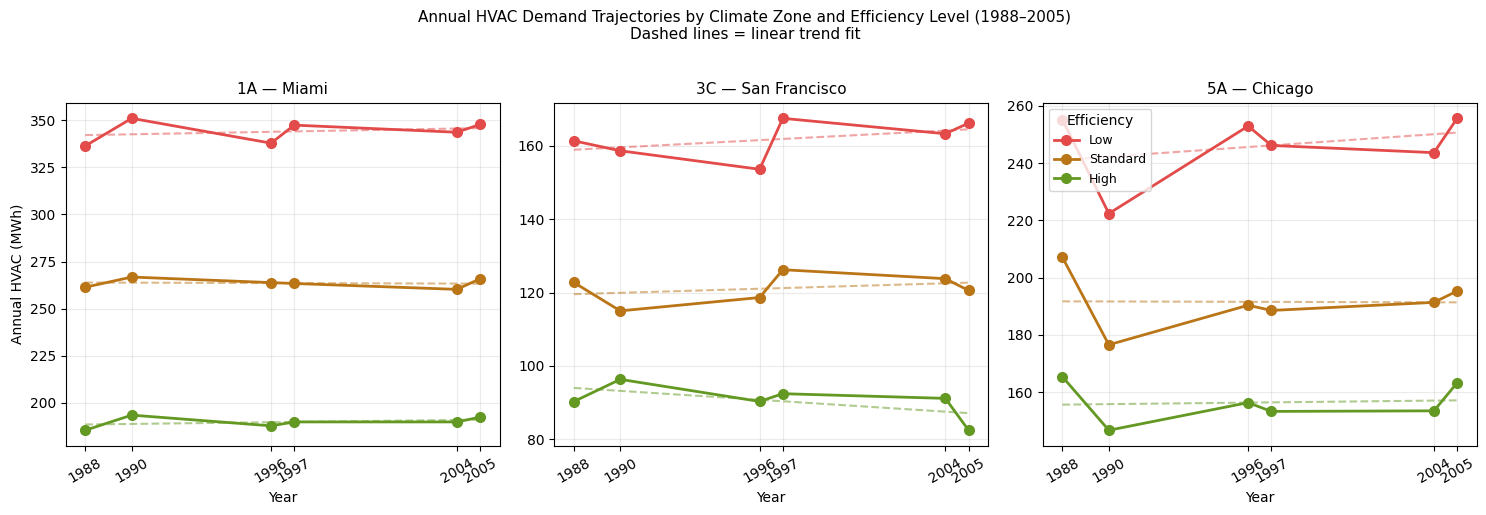

Saved → figures/05_annual_hvac_trajectory.png


In [14]:
# ── Plot annual HVAC trajectory per climate ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Annual HVAC Demand Trajectories by Climate Zone and Efficiency Level (1988–2005)\n'
    'Dashed lines = linear trend fit',
    fontsize=11, y=1.02
)

for ax, clim in zip(axes, CLIMATE_ZONES):
    for eff in EFFICIENCY_LEVELS:
        sub = ann[(ann['climate'] == clim) & (ann['efficiency'] == eff)].sort_values('year_int')
        color = EFFICIENCY_COLOURS[eff]
        ax.plot(sub['year_int'], sub['annual_hvac_mwh'],
                'o-', color=color, lw=2, ms=7, label=eff)

        row = trend_df[(trend_df['climate'] == clim) & (trend_df['efficiency'] == eff)]
        if len(row):
            xs = np.array([sub['year_int'].min(), sub['year_int'].max()])
            m, b, *_ = linregress(sub['year_int'], sub['annual_hvac_mwh'])
            ax.plot(xs, m * xs + b, '--', color=color, alpha=0.5, lw=1.5)

    city = CLIMATE_ZONES[clim].split(',')[0]
    ax.set_title(f'{clim} — {city}', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual HVAC (MWh)' if ax is axes[0] else '')
    ax.grid(alpha=0.25)
    ax.set_xticks(sorted(ann['year_int'].unique()))
    ax.tick_params(axis='x', rotation=30)
    if ax is axes[-1]:
        ax.legend(title='Efficiency', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_OUT / '05_annual_hvac_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/05_annual_hvac_trajectory.png')

## 6. Save Outputs

Saves:
- `data/processed/climate_sensitivity.json` — per-(climate, efficiency) sensitivity coefficients β_CDD, β_HDD, trend slope, R², used by notebooks 06 and 07.
- All four figures to `figures/05_*.png`.

In [15]:
# ── Build and save climate_sensitivity.json ───────────────────────
sensitivity_dict = {}

for _, row in sens_df.iterrows():
    key    = f"{row['climate']}_{row['efficiency']}"
    tr     = trend_df[(trend_df['climate'] == row['climate']) &
                      (trend_df['efficiency'] == row['efficiency'])]
    cf_row = cf[(cf['climate'] == row['climate']) & (cf['efficiency'] == row['efficiency'])]

    sensitivity_dict[key] = {
        'climate':    row['climate'],
        'efficiency': row['efficiency'],
        'beta_CDD_mwh_per_dd':  round(row['beta_CDD_mwh_per_dd'], 4),
        'beta_HDD_mwh_per_dd':  round(row['beta_HDD_mwh_per_dd'], 4),
        'beta_CDD_kwh_m2_dd':   round(row['beta_CDD_kwh_m2_dd'],  5),
        'beta_HDD_kwh_m2_dd':   round(row['beta_HDD_kwh_m2_dd'],  5),
        'p_CDD': round(row['p_CDD'], 4),
        'p_HDD': round(row['p_HDD'], 4),
        'R2_adj_sensitivity':        round(row['R2_adj'], 4),
        'trend_slope_mwh_yr':        round(tr['slope_mwh_yr'].values[0],   4) if len(tr) else None,
        'trend_pct_per_yr':          round(tr['trend_pct_yr'].values[0],    4) if len(tr) else None,
        'trend_R2':                  round(tr['R2'].values[0],              4) if len(tr) else None,
        'trend_p_value':             round(tr['p_value'].values[0],         4) if len(tr) else None,
        'warming_delta_1988_2005_mwh': round(cf_row['delta_total_mwh'].values[0], 2) if len(cf_row) else None,
        'warming_delta_pct':           round(cf_row['delta_pct'].values[0],        2) if len(cf_row) else None,
    }

dd_dict = {
    f"{row['climate']}_{row['year']}": {'CDD': round(row['CDD'], 1), 'HDD': round(row['HDD'], 1)}
    for _, row in dd.iterrows()
}

output = {
    'notebook': '05_climate_trends',
    'CDD_base_C': CDD_BASE,
    'HDD_base_C': HDD_BASE,
    'years_analysed': AMY_YEARS_PIVOT,
    'building_area_m2': AREA_M2,
    'degree_days': dd_dict,
    'sensitivity': sensitivity_dict,
}

out_path = DATA_IN / 'climate_sensitivity.json'
with open(out_path, 'w') as fh:
    json.dump(output, fh, indent=2)

print(f'Saved → data/processed/climate_sensitivity.json  ({out_path.stat().st_size / 1024:.1f} kB)')
print(f'Keys  : {list(sensitivity_dict.keys())}')

Saved → data/processed/climate_sensitivity.json  (5.9 kB)
Keys  : ['1A_Low', '1A_Standard', '1A_High', '3C_Low', '3C_Standard', '3C_High', '5A_Low', '5A_Standard', '5A_High']


In [16]:
# ── Summary table for thesis Chapter 5 ───────────────────────────
print('=' * 88)
print('NOTEBOOK 05 — SUMMARY FOR THESIS CHAPTER 5')
print('=' * 88)

print('\n1. Degree-day trends (1988–2005, linear fit):')
for clim in CLIMATE_ZONES:
    g = dd[dd['climate'] == clim].sort_values('year_int')
    m_c, _, _, p_c, _ = linregress(g['year_int'], g['CDD'])
    m_h, _, _, p_h, _ = linregress(g['year_int'], g['HDD'])
    city = CLIMATE_ZONES[clim].split(',')[0]
    print(f'  {clim} {city}: ΔCDD = {m_c:+.1f} dd/yr (p={p_c:.2f}),  ΔHDD = {m_h:+.1f} dd/yr (p={p_h:.2f})')

print('\n2. Climate sensitivity β_CDD (Standard, MWh per °C·day):')
for clim in CLIMATE_ZONES:
    row = sens_df[(sens_df['climate'] == clim) & (sens_df['efficiency'] == 'Standard')].iloc[0]
    city = CLIMATE_ZONES[clim].split(',')[0]
    print(f'  {clim} {city}: β_CDD = {row["beta_CDD_mwh_per_dd"]:.3f} MWh/dd  '
          f'({row["beta_CDD_kwh_m2_dd"]*1000:.2f} kWh/m²/dd)')

print('\n3. Warming-attributable demand (Standard, 2005 vs 1988):')
for clim in CLIMATE_ZONES:
    row = cf[(cf['climate'] == clim) & (cf['efficiency'] == 'Standard')]
    if not row.empty:
        row = row.iloc[0]
        city = CLIMATE_ZONES[clim].split(',')[0]
        print(f'  {clim} {city}: {row["delta_total_mwh"]:+.1f} MWh/yr  ({row["delta_pct"]:+.1f}%)  '
              f'→  cooling {row["delta_cooling_mwh"]:+.1f} MWh,  heating {row["delta_heating_mwh"]:+.1f} MWh')

print('\n4. Figures saved:')
for fn in ['05_cdd_hdd_trends.png', '05_climate_sensitivity.png',
           '05_warming_counterfactual.png', '05_annual_hvac_trajectory.png']:
    p = FIG_OUT / fn
    exists = 'OK' if p.exists() else 'MISSING'
    print(f'  [{exists}]  figures/{fn}')

print('\nNotebook 05 complete. Next: 06_grid_carbon.ipynb (Objective O4).')

NOTEBOOK 05 — SUMMARY FOR THESIS CHAPTER 5

1. Degree-day trends (1988–2005, linear fit):
  1A Miami: ΔCDD = -6.0 dd/yr (p=0.29),  ΔHDD = +0.1 dd/yr (p=0.96)
  3C San Francisco: ΔCDD = -1.9 dd/yr (p=0.37),  ΔHDD = -13.9 dd/yr (p=0.04)
  5A Chicago: ΔCDD = -1.8 dd/yr (p=0.89),  ΔHDD = -15.1 dd/yr (p=0.46)

2. Climate sensitivity β_CDD (Standard, MWh per °C·day):
  1A Miami: β_CDD = 0.016 MWh/dd  (3.23 kWh/m²/dd)
  3C San Francisco: β_CDD = 0.085 MWh/dd  (17.04 kWh/m²/dd)
  5A Chicago: β_CDD = 0.045 MWh/dd  (8.95 kWh/m²/dd)

3. Warming-attributable demand (Standard, 2005 vs 1988):
  1A Miami: +4.4 MWh/yr  (+1.7%)  →  cooling +6.6 MWh,  heating -0.4 MWh
  3C San Francisco: -2.2 MWh/yr  (-1.8%)  →  cooling +7.1 MWh,  heating -9.5 MWh
  5A Chicago: -11.8 MWh/yr  (-5.7%)  →  cooling +7.8 MWh,  heating -19.7 MWh

4. Figures saved:
  [OK]  figures/05_cdd_hdd_trends.png
  [OK]  figures/05_climate_sensitivity.png
  [OK]  figures/05_warming_counterfactual.png
  [OK]  figures/05_annual_hvac_trajec